# Assignment Two:  Sentiment Classification

For this exercise you will be using the "SemEval 2017 task 4" corpus provided on the module website, available through the following link: https://warwick.ac.uk/fac/sci/dcs/teaching/material/cs918/semeval-tweets.tar.bz2 You will focus particularly on Subtask A, i.e. classifying the overall sentiment of a tweet as positive, negative or neutral.

You are requested to produce a Jupyter notebook for the coursework submission. The input to your program is the SemEval data downloaded. Note that TAs need to run your program on their own machine by using the original SemEval data. As such, don’t submit a Python program that takes as input some preprocessed files.

#### Import necessary packages
You may import more packages here.

In [3]:
# Import necessary packages

# Standard library
import os
import re
import time
from collections import Counter
from os.path import join

# Data handling
import numpy as np
import pandas as pd

# Natural Language Processing
import nltk
from nltk.stem import WordNetLemmatizer

# Visualization
import matplotlib.pyplot as plt

# scikit‑learn
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit, GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import normalize, StandardScaler
from sklearn.svm import LinearSVC

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Hugging Face Transformers
from transformers import BertForSequenceClassification, BertTokenizer, Trainer, TrainingArguments, pipeline

# Progress bars
from tqdm import tqdm

# Download NLTK data
nltk.download('wordnet')
nltk.download('omw-1.4')



[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\abdul\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\abdul\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [4]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install transformers datasets

Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [7]:
pip install transformers[torch]

Note: you may need to restart the kernel to use updated packages.


In [8]:
pip install pyarrow --upgrade

Note: you may need to restart the kernel to use updated packages.


In [9]:
# Define test sets
testsets = ['twitter-test1.txt', 'twitter-test2.txt', 'twitter-test3.txt']

In [10]:
# Skeleton: Evaluation code for the test sets
def read_test(testset):
    '''
    readin the testset and return a dictionary
    :param testset: str, the file name of the testset to compare
    '''
    id_gts = {}
    with open(testset, 'r', encoding='utf8') as fh:
        for line in fh:
            fields = line.split('\t')
            tweetid = fields[0]
            gt = fields[1]

            id_gts[tweetid] = gt

    return id_gts


def confusion(id_preds, testset, classifier):
    '''
    print the confusion matrix of {'positive', 'netative'} between preds and testset
    :param id_preds: a dictionary of predictions formated as {<tweetid>:<sentiment>, ... }
    :param testset: str, the file name of the testset to compare
    :classifier: str, the name of the classifier
    '''
    id_gts = read_test(testset)

    gts = []
    for m, c1 in id_gts.items():
        if c1 not in gts:
            gts.append(c1)

    gts = ['positive', 'negative', 'neutral']

    conf = {}
    for c1 in gts:
        conf[c1] = {}
        for c2 in gts:
            conf[c1][c2] = 0

    for tweetid, gt in id_gts.items():
        if tweetid in id_preds:
            pred = id_preds[tweetid]
        else:
            pred = 'neutral'
        conf[pred][gt] += 1

    print(''.ljust(12) + '  '.join(gts))

    for c1 in gts:
        print(c1.ljust(12), end='')
        for c2 in gts:
            if sum(conf[c1].values()) > 0:
                print('%.3f     ' % (conf[c1][c2] / float(sum(conf[c1].values()))), end='')
            else:
                print('0.000     ', end='')
        print('')

    print('')


def evaluate(id_preds, testset, classifier):
    '''
    print the macro-F1 score of {'positive', 'netative'} between preds and testset
    :param id_preds: a dictionary of predictions formated as {<tweetid>:<sentiment>, ... }
    :param testset: str, the file name of the testset to compare
    :classifier: str, the name of the classifier
    '''
    id_gts = read_test(testset)

    acc_by_class = {}
    for gt in ['positive', 'negative', 'neutral']:
        acc_by_class[gt] = {'tp': 0, 'fp': 0, 'tn': 0, 'fn': 0}

    catf1s = {}

    ok = 0
    for tweetid, gt in id_gts.items():
        if tweetid in id_preds:
            pred = id_preds[tweetid]
        else:
            pred = 'neutral'

        if gt == pred:
            ok += 1
            acc_by_class[gt]['tp'] += 1
        else:
            acc_by_class[gt]['fn'] += 1
            acc_by_class[pred]['fp'] += 1

    catcount = 0
    itemcount = 0
    macro = {'p': 0, 'r': 0, 'f1': 0}
    micro = {'p': 0, 'r': 0, 'f1': 0}
    semevalmacro = {'p': 0, 'r': 0, 'f1': 0}

    microtp = 0
    microfp = 0
    microtn = 0
    microfn = 0
    for cat, acc in acc_by_class.items():
        catcount += 1

        microtp += acc['tp']
        microfp += acc['fp']
        microtn += acc['tn']
        microfn += acc['fn']

        p = 0
        if (acc['tp'] + acc['fp']) > 0:
            p = float(acc['tp']) / (acc['tp'] + acc['fp'])

        r = 0
        if (acc['tp'] + acc['fn']) > 0:
            r = float(acc['tp']) / (acc['tp'] + acc['fn'])

        f1 = 0
        if (p + r) > 0:
            f1 = 2 * p * r / (p + r)

        catf1s[cat] = f1

        n = acc['tp'] + acc['fn']

        macro['p'] += p
        macro['r'] += r
        macro['f1'] += f1

        if cat in ['positive', 'negative']:
            semevalmacro['p'] += p
            semevalmacro['r'] += r
            semevalmacro['f1'] += f1

        itemcount += n

    micro['p'] = float(microtp) / float(microtp + microfp)
    micro['r'] = float(microtp) / float(microtp + microfn)
    micro['f1'] = 2 * float(micro['p']) * micro['r'] / float(micro['p'] + micro['r'])

    semevalmacrof1 = semevalmacro['f1'] / 2

    print(testset + ' (' + classifier + '): %.3f' % semevalmacrof1)

#### Load training set, dev set and testing set
Here, you need to load the training set, the development set and the test set. For better classification results, you may need to preprocess tweets before sending them to the classifiers.

In [12]:
# Load training set, dev set and testing set
data = {}
tweetids = {}
tweetgts = {}
tweets = {}

lemmatizer = WordNetLemmatizer()

# Start timing the loading process.
start_time = time.time()

for dataset in ['twitter-training-data.txt'] + ['twitter-dev-data.txt'] + testsets:
    data[dataset] = []
    tweets[dataset] = []
    tweetids[dataset] = []
    tweetgts[dataset] = []

    # Construct the full file path.
    dataset_path = join('semeval-tweets', dataset)    

    # write code to read in the datasets here
    with open(dataset_path, 'r', encoding='utf8') as f:
        for line in f:
            # Split the line by tab; expected format: tweet-id, sentiment, tweet-text
            fields = line.strip().split('\t')
            if len(fields) < 3:
                continue  # skip lines that do not have all three fields
                
            tweet_id = fields[0]
            sentiment = fields[1]
            tweet_text = fields[2]
            
            # Preprocessing Steps (from assingment 1):
            # 1. Lowercase all text.
            cleaned_text = tweet_text.lower()
            
            # 2. Remove URLs.
            cleaned_text = re.sub(r'https?://\S+', '', cleaned_text)
            cleaned_text = re.sub(r'www\.\S+', '', cleaned_text)
            
            # 3. Remove or tweak hashtags and mentions, but keep the following word
            cleaned_text = re.sub(r'@(\w+)', r'\1', cleaned_text)
            cleaned_text = re.sub(r'#(\w+)', r'\1', cleaned_text)
            
            # 4. Remove all non-alphanumeric characters except spaces.
            cleaned_text = re.sub(r'[^a-z0-9\s]', '', cleaned_text)
            
            # 5. Tokenize text (split by whitespace).
            tokens = cleaned_text.split()
            
            # 6. Remove words with only one character and tokens that are entirely numeric.
            tokens = [token for token in tokens if len(token) > 1 and not token.isdigit()]
            
            # 7. Lemmatize each token.
            tokens = [lemmatizer.lemmatize(token) for token in tokens]
            
            # Reassemble tokens back into a string.
            cleaned_text = " ".join(tokens)
            
            # Append data into corresponding dictionaries
            data[dataset].append((tweet_id, sentiment, cleaned_text))
            tweetids[dataset].append(tweet_id)
            tweetgts[dataset].append(sentiment)
            tweets[dataset].append(cleaned_text)

# End timing the loading process.
end_time = time.time()
print("Data loading and preprocessing took {:.3f} seconds.".format(end_time - start_time))

Data loading and preprocessing took 3.435 seconds.


## Validating that data is being loaded in correctly:

In [14]:
# Print 5 sample tweets from the training set to verify data loading
print("Sample tweets from 'twitter-training-data.txt':\n")
for i in range(5):
    print("Tweet ID:", tweetids['twitter-training-data.txt'][i])
    print("Sentiment:", tweetgts['twitter-training-data.txt'][i])
    print("Tweet:", tweets['twitter-training-data.txt'][i])
    print("-" * 50)

Sample tweets from 'twitter-training-data.txt':

Tweet ID: 335104872099066692
Sentiment: positive
Tweet: felt privileged to play foo fighter song on guitar today with one of the plectrum from the gig on saturday
--------------------------------------------------
Tweet ID: 796528524030124618
Sentiment: positive
Tweet: aaqibafzaal pakistan may be an islamic country but der are lot true muslim in india who love their country and can sacrifice all for it
--------------------------------------------------
Tweet ID: 760964834217238632
Sentiment: positive
Tweet: happy birthday to the coolest golfer in bali tjvictoriacnd may you become cooler and cooler everyday stay humble little sister xx
--------------------------------------------------
Tweet ID: 147713180324524046
Sentiment: negative
Tweet: simpplya tmills is going to tucson but the 29th and it on thursday
--------------------------------------------------
Tweet ID: 732302280474120023
Sentiment: negative
Tweet: hmmmmm where are the blackl

#### Build sentiment classifiers
You need to create your own classifiers (at least 3 classifiers). For each classifier, you can choose between the bag-of-word features and the word-embedding-based features. Each classifier has to be evaluated over 3 test sets. Make sure your classifier produce consistent performance across the test sets. Marking will be based on the performance over all 5 test sets (2 of them are not provided to you).

## Helper functions for the BERT classifier:

In [17]:
# ------------------------------
# 1. Define Label Mapping
# ------------------------------
label2id = {'positive': 0, 'negative': 1, 'neutral': 2}
id2label = {v: k for k, v in label2id.items()}

# ------------------------------
# 2. Data Loading Function
# ------------------------------
def load_data(filepath):
    """
    Load tweet data from a TSV file.

    The file is expected to contain tweet_id, sentiment, and tweet_text.
    Inconsistent delimiters are handled by first attempting to split on tabs;
    if that fails to produce at least three parts, the line is split using whitespace (with a maximum of 2 splits).

    Parameters:
        filepath (str): Path to the TSV file containing tweet data.

    Returns:
        pd.DataFrame: A DataFrame with columns ['tweet_id', 'sentiment', 'tweet_text'].
    """
    data = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            # Attempt to split using tab as the delimiter.
            parts = line.split('\t')
            # If splitting by tab doesn't yield enough parts, split by whitespace.
            if len(parts) < 3:
                parts = line.split(None, 2)
            if len(parts) >= 3:
                tweet_id, sentiment, tweet_text = parts[0], parts[1], parts[2]
                data.append((tweet_id, sentiment, tweet_text))
            else:
                print("Skipping line (unable to parse):", line)
    return pd.DataFrame(data, columns=['tweet_id', 'sentiment', 'tweet_text'])


# ------------------------------
# 3. Define TweetDataset Class
# ------------------------------
class TweetDataset(Dataset):
    """
    Dataset class for tweet data that supports both BERT and LSTM modes.

    For BERT mode, a tokenizer (e.g., a BERT tokenizer) must be provided.
    For LSTM mode, a word_to_index mapping must be provided.

    Parameters:
        texts (list of str): List of tweet texts.
        labels (list of str): List of sentiment labels corresponding to the tweets.
        ids (list): List of unique tweet identifiers.
        tokenizer (object, optional): Tokenizer instance for BERT mode. Defaults to None.
        word_to_index (dict, optional): Mapping from words to indices for LSTM mode. Defaults to None.
        max_length (int, optional): Maximum sequence length for tokenization. Defaults to 128.
    """
    def __init__(self, texts, labels, ids, tokenizer: object = None, word_to_index: dict = None, max_length: int = 128):
        self.texts = texts
        self.labels = labels
        self.ids = ids
        self.tokenizer = tokenizer
        self.word_to_index = word_to_index
        self.max_length = max_length
        self.label2idx = {'positive': 0, 'negative': 1, 'neutral': 2}

        # Ensure that a word_to_index mapping is provided when not in BERT mode.
        if self.tokenizer is None and self.word_to_index is None:
            raise ValueError("For LSTM mode, a word_to_index mapping must be provided.")

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label_str = self.labels[idx]
        tweet_id = self.ids[idx]

        # Convert the sentiment label to its corresponding integer index.
        label = self.label2idx.get(label_str, -1)
        if label == -1:
            raise ValueError(f"Unknown label: {label_str}")

        # BERT mode: use the provided tokenizer to encode the text.
        if self.tokenizer is not None:
            encoding = self.tokenizer(
                text,
                truncation=True,
                padding='max_length',
                max_length=self.max_length,
                return_tensors='pt'
            )
            # Remove the batch dimension.
            item = {k: v.squeeze(0) for k, v in encoding.items()}
            item['labels'] = torch.tensor(label, dtype=torch.long)
            item['tweet_id'] = tweet_id
            return item
        else:
            # LSTM mode: tokenize text using a simple split and convert tokens to indices.
            tokens = text.split()
            seq = [self.word_to_index.get(tok, 0) for tok in tokens]
            # Pad or truncate the sequence to ensure a fixed length.
            seq = seq[:self.max_length] + [0] * max(0, self.max_length - len(seq))
            return (
                torch.tensor(seq, dtype=torch.long),
                torch.tensor(label, dtype=torch.long),
                tweet_id
            )


# ------------------------------
# 4. Inference Function Using a Progress Bar
# ------------------------------
def get_predictions(dataset, model, device):
    """
    Generate sentiment predictions for a dataset using a BERT model.

    Processes the dataset in batches with a progress bar and maps tweet IDs to predicted sentiment labels.

    Parameters:
        dataset (TweetDataset): Dataset instance containing tweet data.
        model (nn.Module): The BERT model used for inference.
        device (torch.device): The device (CPU or GPU) on which to perform inference.

    Returns:
        dict: A dictionary mapping tweet IDs to predicted sentiment labels.
    """
    id_preds = {}
    total_samples = 0
    start = time.time()
    dataloader = DataLoader(dataset, batch_size=16, shuffle=False)

    for batch in tqdm(dataloader, desc="Inferring", unit="batch"):
        # Move input tensors to the specified device.
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        with torch.no_grad():
            logits = model(input_ids, attention_mask)

        preds = torch.argmax(logits, dim=-1).cpu().numpy()
        for tweet_id, pred in zip(batch['tweet_id'], preds):
            id_preds[tweet_id] = id2label[pred]
        total_samples += input_ids.size(0)

    elapsed = time.time() - start
    print(f"Inference speed: {total_samples / elapsed:.2f} samples/second")
    return id_preds

## Helper functions for the LSTM classifier:

In [19]:
############################## LSTM HELPERS END HERE ############################################################
#################################################################################################################
def predict_on_dataset(model, texts, tweet_ids, word_to_index, max_seq_len, idx2label):
    """
    Predict sentiment labels for a list of tweets using a trained LSTM model.

    Parameters:
        model (nn.Module): Trained LSTM model.
        texts (list of str): List of tweet texts.
        tweet_ids (list): List of tweet IDs corresponding to each tweet.
        word_to_index (dict): Mapping from words to their indices.
        max_seq_len (int): Maximum sequence length for padding/truncation.
        idx2label (dict): Mapping from predicted index to sentiment label.

    Returns:
        dict: A dictionary mapping tweet IDs to predicted sentiment labels.
    """
    model.eval()
    id_preds = {}
    with torch.no_grad():
        for i, tweet in enumerate(texts):
            tokens = tweet.split()
            # Convert tokens to indices; default to 0 if token is not found.
            seq = [word_to_index.get(token, 0) for token in tokens]
            # Pad or truncate the sequence to ensure fixed length.
            if len(seq) < max_seq_len:
                seq = seq + [0] * (max_seq_len - len(seq))
            else:
                seq = seq[:max_seq_len]
            # Create a tensor with shape (1, max_seq_len) for model input.
            seq_tensor = torch.tensor(seq, dtype=torch.long).unsqueeze(0)
            outputs = model(seq_tensor)
            _, predicted = torch.max(outputs, 1)
            pred_label = idx2label[predicted.item()]
            id_preds[tweet_ids[i]] = pred_label
    return id_preds


def compute_max_length(tweets_dict):
    """
    Compute the maximum tweet length (in token count) across all datasets.

    Parameters:
        tweets_dict (dict): A dictionary where keys are dataset names and values are lists of tweet texts.

    Returns:
        int: The maximum number of tokens found in any tweet.
    """
    max_length = 0
    for dataset in tweets_dict:
        for tweet in tweets_dict[dataset]:
            length = len(tweet.split())
            if length > max_length:
                max_length = length
    return max_length


class LSTMClassifier(nn.Module):
    """
    LSTM-based classifier for sentiment analysis.

    Parameters:
        vocab_size (int): Size of the vocabulary.
        embed_dim (int): Dimensionality of word embeddings.
        hidden_dim (int): Number of features in the LSTM hidden state.
        num_classes (int): Number of sentiment classes.
        embedding_matrix (np.ndarray): Pre-trained embedding matrix.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, embedding_matrix):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        # Copy pre-trained embeddings into the embedding layer.
        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))
        # Freeze the embedding layer weights to prevent updates during training.
        self.embedding.weight.requires_grad = False
        # Define the LSTM layer; setting batch_first=True means the input tensor shape is (batch, seq, feature).
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        # Define a fully connected layer to map the LSTM output to sentiment classes.
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        """
        Forward pass of the LSTMClassifier.

        Parameters:
            x (torch.Tensor): Input tensor of shape (batch_size, max_seq_len).

        Returns:
            torch.Tensor: Output logits for each sentiment class.
        """
        # Pass input through the embedding and LSTM layers.
        _, (h_n, _) = self.lstm(self.embedding(x))
        # Remove the singleton dimension from h_n and apply the fully connected layer.
        return self.fc(h_n.squeeze(0))

############################## LSTM HELPERS END HERE ###################################################
########################################################################################################

## Helper function for the few-shot prompting classifier:

In [21]:
def classify_with_flan(tweet, few_shot_prompt, classifier, max_new_tokens=16):
    """
    Classify a tweet using few-shot prompting with Flan‑T5.

    Constructs a prompt by appending the tweet to the few-shot prompt, then returns
    the first token of the generated text if it matches a valid sentiment label.
    
    Parameters:
        tweet (str): The tweet text.
        few_shot_prompt (str): The few-shot prompt containing examples.
        classifier: The Flan‑T5 pipeline instance.
        max_new_tokens (int, optional): Maximum number of tokens to generate. Defaults to 16.

    Returns:
        str: The predicted sentiment ("positive", "negative", or "neutral").
    """
    prompt = few_shot_prompt + f"Tweet: {tweet}\nSentiment:"
    out = classifier(prompt, max_new_tokens=max_new_tokens, do_sample=False)[0]["generated_text"].strip().lower()
    first = out.split()[0]
    return first if first in {"positive", "negative", "neutral"} else "neutral"


# Main code:

Loading GloVe embeddings from glove_data\glove.6B.100d.txt ...
Loaded GloVe embeddings in 7.501 seconds.
Training svm with features bow
GridSearchCV took 11.370 seconds.
semeval-tweets\twitter-test1.txt (bow-svm): 0.601
semeval-tweets\twitter-test2.txt (bow-svm): 0.608
semeval-tweets\twitter-test3.txt (bow-svm): 0.567
Training svm with features avg-glove
Feature set avg-glove not implemented for svm
Computed training features in 1.140 seconds.
Fitting LinearSVC on training data...


C:\Users\abdul\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


Fitted in 4.061s
semeval-tweets\twitter-test1.txt (avg-glove-svm): 0.418
semeval-tweets\twitter-test2.txt (avg-glove-svm): 0.414
semeval-tweets\twitter-test3.txt (avg-glove-svm): 0.449
Training MaxEnt with features bow
MaxEnt fitting took 16.361 seconds.
semeval-tweets\twitter-test1.txt (bow-MaxEnt): 0.538
semeval-tweets\twitter-test2.txt (bow-MaxEnt): 0.538
semeval-tweets\twitter-test3.txt (bow-MaxEnt): 0.519
Training MaxEnt with features avg-glove
Computing average GloVe training features...
Computed training features in 1.371s
Fitting LogisticRegression on training data...
Fitted in 2.476s
semeval-tweets\twitter-test1.txt (avg-glove-MaxEnt): 0.562
semeval-tweets\twitter-test2.txt (avg-glove-MaxEnt): 0.575
semeval-tweets\twitter-test3.txt (avg-glove-MaxEnt): 0.533
Training BERT
Loading tokenizer from bert_model_quant
Loading quantized model from bert_model_quant\bert_quantized.pt
Quantized model loaded and moved to cpu.

Processing twitter-test1.txt...


Inferring: 100%|██████████| 221/221 [05:14<00:00,  1.42s/batch]


Inference speed: 11.23 samples/second
Evaluation on twitter-test1.txt took 314.469 seconds.
semeval-tweets\twitter-test1.txt (bert_quantized): 0.721
            positive  negative  neutral
positive    0.774     0.018     0.208     
negative    0.044     0.866     0.090     
neutral     0.173     0.138     0.689     


Processing twitter-test2.txt...


Inferring: 100%|██████████| 116/116 [02:16<00:00,  1.18s/batch]


Inference speed: 13.58 samples/second
Evaluation on twitter-test2.txt took 136.405 seconds.
semeval-tweets\twitter-test2.txt (bert_quantized): 0.714
            positive  negative  neutral
positive    0.801     0.012     0.187     
negative    0.065     0.823     0.113     
neutral     0.247     0.119     0.634     


Processing twitter-test3.txt...


Inferring: 100%|██████████| 149/149 [03:03<00:00,  1.23s/batch]


Inference speed: 12.96 samples/second
Evaluation on twitter-test3.txt took 183.566 seconds.
semeval-tweets\twitter-test3.txt (bert_quantized): 0.704
            positive  negative  neutral
positive    0.826     0.017     0.157     
negative    0.092     0.701     0.207     
neutral     0.223     0.115     0.662     

Training LSTM
Maximum tweet length computed: 32 tokens. Operation took 0.111s
Maximum tweet length is: 32
Starting LSTM training...
Epoch 1/7 — Train Loss: 1.0365, Dev Loss: 1.0406
Epoch 2/7 — Train Loss: 0.9764, Dev Loss: 0.8726
Epoch 3/7 — Train Loss: 0.8175, Dev Loss: 0.7844
Epoch 4/7 — Train Loss: 0.7740, Dev Loss: 0.7585
Epoch 5/7 — Train Loss: 0.7442, Dev Loss: 0.7399
Epoch 6/7 — Train Loss: 0.7183, Dev Loss: 0.7337
Epoch 7/7 — Train Loss: 0.6908, Dev Loss: 0.7345
Training completed in 312.837s


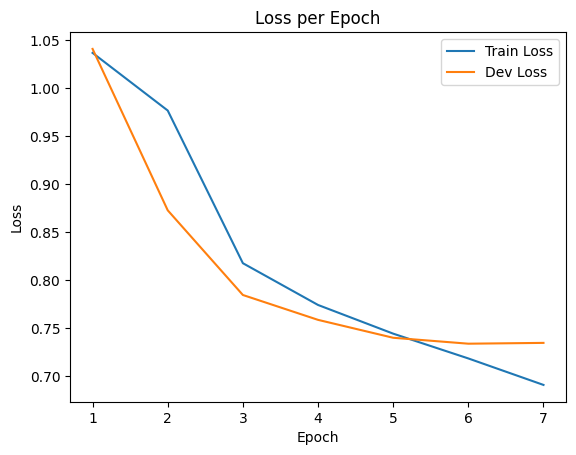

Evaluating on twitter-test1.txt...
semeval-tweets\twitter-test1.txt (lstm): 0.602
twitter-test1.txt evaluation took 12.890 seconds.
Evaluating on twitter-test2.txt...
semeval-tweets\twitter-test2.txt (lstm): 0.598
twitter-test2.txt evaluation took 7.408 seconds.
Evaluating on twitter-test3.txt...
semeval-tweets\twitter-test3.txt (lstm): 0.565
twitter-test3.txt evaluation took 8.703 seconds.
Creating new test subset files...
Created test_subsets\twitter-test1_subset.txt with 60 samples.
Created test_subsets\twitter-test2_subset.txt with 60 samples.
Created test_subsets\twitter-test3_subset.txt with 60 samples.

Few-shot prompt built:
Tweet: @cubsfunduh @Cubs @JArrieta34 The last run I saw was against the White Sox with two outs in the 6th... Still really good streak regardless.
Sentiment: positive

Tweet: SHARKNADO 3 tomorrow!??? Best day of my life
Sentiment: positive

Tweet: How about a little Facebook Fun Friday! Like this post for a chance to win a $10 gift card to Dunkin' Donuts...

Device set to use cpu



Processing twitter-test1_subset.txt ...
Inference on twitter-test1_subset.txt completed in 57.272 seconds.
test_subsets\twitter-test1_subset.txt (prompting_few_shot): 0.750
            positive  negative  neutral
positive    0.500     0.000     0.500     
negative    0.115     0.769     0.115     
neutral     0.000     0.000     0.000     


Processing twitter-test2_subset.txt ...
Inference on twitter-test2_subset.txt completed in 55.759 seconds.
test_subsets\twitter-test2_subset.txt (prompting_few_shot): 0.727
            positive  negative  neutral
positive    0.485     0.000     0.515     
negative    0.148     0.741     0.111     
neutral     0.000     0.000     0.000     


Processing twitter-test3_subset.txt ...
Inference on twitter-test3_subset.txt completed in 57.017 seconds.
test_subsets\twitter-test3_subset.txt (prompting_few_shot): 0.656
            positive  negative  neutral
positive    0.619     0.000     0.381     
negative    0.179     0.513     0.308     
neutral     

In [27]:
# Buid traditional sentiment classifiers. An example classifier name 'svm' is given
# in the code below. You should replace the other two classifier names
# with your own choices. For features used for classifier training, 
# the 'bow' feature is given in the code. But you could also explore the 
# use of other features.

########################################################################
# Load GloVe embeddings
########################################################################
glove_path = join('glove_data', 'glove.6B.100d.txt')
print("Loading GloVe embeddings from", glove_path, "...")
start_time = time.time()

glove_embeddings = {}
with open(glove_path, 'r', encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        glove_embeddings[word] = vector

end_time = time.time()
print("Loaded GloVe embeddings in {:.3f} seconds.".format(end_time - start_time))


def avg_max_glove_vector(tweet, glove_embeddings, embedding_dim):
    """
    Compute the concatenation of the average and maximum GloVe vectors for a tweet.

    Parameters:
        tweet (str): The tweet text.
        glove_embeddings (dict): Mapping of words to their GloVe vectors.
        embedding_dim (int): The dimensionality of the GloVe embeddings.

    Returns:
        np.ndarray: A vector of length 2 * embedding_dim, combining average and max pooled features.
    """
    tokens = tweet.split()
    valid_vectors = [glove_embeddings[word] for word in tokens if word in glove_embeddings]

    if valid_vectors:
        avg_vec = np.mean(valid_vectors, axis=0)
        max_vec = np.max(valid_vectors, axis=0)
        return np.concatenate([avg_vec, max_vec])
    else:
        return np.zeros(2 * embedding_dim)


# Iterate over classifiers and feature sets for training
for classifier in ["svm", "MaxEnt", "BERT", "LSTM", "PromptingLLM"]:
    for features in ["bow", "avg-glove"]:
        # Skeleton: Creation and training of the classifiers
        if classifier == "svm":
            print(f"Training {classifier} with features {features}")

            if features == "bow":
                # Define hyperparameter grid for grid search
                param_grid = {
                    'C': [0.1, 1, 10],
                    'loss': ['squared_hinge'],
                    'dual': ["auto"]
                }

                # Create a TF-IDF vectorizer and transform the training tweets
                vectorizer = TfidfVectorizer(ngram_range=(1, 2))
                X_train = vectorizer.fit_transform(tweets['twitter-training-data.txt'])
                y_train = tweetgts['twitter-training-data.txt']

                # Instantiate a LinearSVC classifier
                svm_clf = LinearSVC(random_state=21)

                # Create the GridSearchCV object (3-fold cross-validation)
                grid_search = GridSearchCV(
                    svm_clf,
                    param_grid,
                    scoring='f1_weighted',
                    cv=3,
                    n_jobs=-1
                )

                # Time the grid search process
                start_time = time.time()
                grid_search.fit(X_train, y_train)
                end_time = time.time()

                print("GridSearchCV took {:.3f} seconds.".format(end_time - start_time))

            elif features == "avg-glove":
                print(f"Feature set {features} not implemented for svm")

                # Compute training features using average and max pooled GloVe embeddings
                start_time = time.time()
                X_train = np.array([
                    avg_max_glove_vector(tweet, glove_embeddings, 100)
                    for tweet in tweets['twitter-training-data.txt']
                ])
                X_train = normalize(X_train, norm='l2')
                y_train = tweetgts['twitter-training-data.txt']
                end_time = time.time()
                print("Computed training features in {:.3f} seconds.".format(end_time - start_time))

                # Train a LinearSVC classifier with reproducibility settings
                svm_clf = LinearSVC(random_state=21, max_iter=10000)
                print("Fitting LinearSVC on training data...")
                start_time = time.time()
                svm_clf.fit(X_train, y_train)
                print(f"Fitted in {time.time() - start_time:.3f}s")

        elif classifier == "MaxEnt":
            print(f"Training {classifier} with features {features}")

            if features == "bow":
                # Initialize and fit the TF-IDF vectorizer on the training data
                vectorizer = TfidfVectorizer(ngram_range=(1, 2))
                X_train = vectorizer.fit_transform(tweets['twitter-training-data.txt'])
                y_train = tweetgts['twitter-training-data.txt']

                start_time = time.time()
                # Create and fit the Maximum Entropy classifier using LogisticRegression
                clf_maxent = LogisticRegression(random_state=42, solver='lbfgs', max_iter=10000)
                clf_maxent.fit(X_train, y_train)
                end_time = time.time()
                print("MaxEnt fitting took {:.3f} seconds.".format(end_time - start_time))

            if features == "avg-glove":
                print("Computing average GloVe training features...")
                start_time = time.time()
                X_train = np.array([
                    avg_max_glove_vector(tweet, glove_embeddings, 100)
                    for tweet in tweets['twitter-training-data.txt']
                ])
                X_train = normalize(X_train, norm='l2')
                y_train = tweetgts['twitter-training-data.txt']
                print(f"Computed training features in {time.time() - start_time:.3f}s")

                # Fit Logistic Regression (Maximum Entropy classifier)
                clf_maxent = LogisticRegression(random_state=21, max_iter=10000, class_weight='balanced')
                print("Fitting LogisticRegression on training data...")
                start_time = time.time()
                clf_maxent.fit(X_train, y_train)
                print(f"Fitted in {time.time() - start_time:.3f}s")

        elif classifier == "BERT":
            # Train BERT classifier using bag-of-words features.
            if features == "bow":
                print(f"Training {classifier}")
                # ------------------------------
                # 5. Load the Tokenizer and Quantized Model
                # ------------------------------
                quant_model_dir = "bert_model_quant"  # Directory containing the quantized & traced model and tokenizer
                print("Loading tokenizer from", quant_model_dir)
                # Load the BERT tokenizer from the specified directory.
                tokenizer = BertTokenizer.from_pretrained(quant_model_dir)
                
                # Construct the full path to the quantized model file.
                quant_model_path = join(quant_model_dir, "bert_quantized.pt")
                print("Loading quantized model from", quant_model_path)
                # Load the quantized (scripted) model and set it to evaluation mode.
                scripted_model = torch.jit.load(quant_model_path)
                scripted_model.eval()
                
                # Move the model to GPU if available.
                device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
                scripted_model.to(device)
                print(f"Quantized model loaded and moved to {device}.")


        
        elif classifier == 'LSTM':
            # Train the LSTM classifier using the Bag-of-Words (bow) feature set.
            if features == 'bow':
                print("Training", classifier)
        
                # ------------------------------
                # Settings and Hyperparameters
                # ------------------------------
                MAX_VOCAB_SIZE = 5000       # Maximum vocabulary size (index 0 reserved for padding)
                EMBEDDING_DIM = 100         # Dimensionality of GloVe embeddings
                BATCH_SIZE = 32             # Batch size for training
                NUM_EPOCHS = 7              # Number of training epochs
                HIDDEN_DIM = 128            # Hidden dimension size for the LSTM
                NUM_CLASSES = 3             # Number of sentiment classes: positive, negative, neutral
        
                # ------------------------------
                # 1. Compute Maximum Tweet Length
                # ------------------------------
                start_time = time.time()
                max_length = compute_max_length(tweets)
                MAX_SEQ_LEN = max_length
                elapsed = time.time() - start_time
                print(f"Maximum tweet length computed: {max_length} tokens. Operation took {elapsed:.3f}s")
                print("Maximum tweet length is:", max_length)
        
                # ------------------------------
                # 2. Build Vocabulary from Training Data
                # ------------------------------
                train_texts = tweets['twitter-training-data.txt']
                # Tokenize all training tweets and count token frequencies.
                all_tokens = [token for tweet in train_texts for token in tweet.split()]
                from collections import Counter
                counter = Counter(all_tokens)
                # Reserve index 0 for padding; select the most common MAX_VOCAB_SIZE-1 tokens.
                most_common = counter.most_common(MAX_VOCAB_SIZE - 1)
                word_to_index = {word: idx + 1 for idx, (word, _) in enumerate(most_common)}
        
                # ------------------------------
                # 3. Build Embedding Matrix Using GloVe
                # ------------------------------
                import numpy as np
                embedding_matrix = np.zeros((MAX_VOCAB_SIZE, EMBEDDING_DIM))
                for word, idx in word_to_index.items():
                    # Use the GloVe vector if available and if within the maximum vocabulary size.
                    vec = glove_embeddings.get(word)
                    if idx < MAX_VOCAB_SIZE and vec is not None:
                        embedding_matrix[idx] = vec
        
                # ------------------------------
                # 4. Define Train and Development Datasets
                # ------------------------------
                train_dataset = TweetDataset(
                    texts=tweets['twitter-training-data.txt'],
                    labels=tweetgts['twitter-training-data.txt'],
                    ids=tweetids['twitter-training-data.txt'],
                    word_to_index=word_to_index,
                    max_length=MAX_SEQ_LEN
                )
                dev_dataset = TweetDataset(
                    texts=tweets['twitter-dev-data.txt'],
                    labels=tweetgts['twitter-dev-data.txt'],
                    ids=tweetids['twitter-dev-data.txt'],
                    word_to_index=word_to_index,
                    max_length=MAX_SEQ_LEN
                )
        
                from torch.utils.data import DataLoader
                train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
                dev_loader = DataLoader(dev_dataset, batch_size=BATCH_SIZE)
        
                # ------------------------------
                # 5. Instantiate LSTMClassifier
                # ------------------------------
                model = LSTMClassifier(
                    vocab_size=MAX_VOCAB_SIZE,
                    embed_dim=EMBEDDING_DIM,
                    hidden_dim=HIDDEN_DIM,
                    num_classes=NUM_CLASSES,
                    embedding_matrix=embedding_matrix
                )
        
                # ------------------------------
                # 6. Train the LSTM Model
                # ------------------------------
                import torch
                import torch.nn as nn
                import torch.optim as optim
        
                criterion = nn.CrossEntropyLoss()
                optimizer = optim.Adam(model.parameters(), lr=1e-3)
        
                print("Starting LSTM training...")
                start_time = time.time()
                train_losses, dev_losses = [], []
        
                for epoch in range(NUM_EPOCHS):
                    model.train()
                    train_loss = 0
                    for inputs, labels, _ in train_loader:
                        optimizer.zero_grad()
                        outputs = model(inputs)
                        loss = criterion(outputs, labels)
                        loss.backward()
                        optimizer.step()
                        train_loss += loss.item() * inputs.size(0)
                    train_loss /= len(train_loader.dataset)
                    train_losses.append(train_loss)
        
                    model.eval()
                    dev_loss = 0
                    with torch.no_grad():
                        for inputs, labels, _ in dev_loader:
                            loss = criterion(model(inputs), labels)
                            dev_loss += loss.item() * inputs.size(0)
                    dev_loss /= len(dev_loader.dataset)
                    dev_losses.append(dev_loss)
        
                    print(f"Epoch {epoch+1}/{NUM_EPOCHS} — Train Loss: {train_loss:.4f}, Dev Loss: {dev_loss:.4f}")
        
                total_training_time = time.time() - start_time
                print(f"Training completed in {total_training_time:.3f}s")
        
                # ------------------------------
                # 7. Plot Training and Development Loss
                # ------------------------------
                import matplotlib.pyplot as plt
                plt.plot(range(1, NUM_EPOCHS + 1), train_losses, label="Train Loss")
                plt.plot(range(1, NUM_EPOCHS + 1), dev_losses, label="Dev Loss")
                plt.xlabel("Epoch")
                plt.ylabel("Loss")
                plt.title("Loss per Epoch")
                plt.legend()
                plt.show()

        else: # Few-shot prompting Flan-T5
            # ------------------------------
            # Create New Test Subset Files
            # ------------------------------
            data_dir = "semeval-tweets"   # Folder with original test files
            subset_dir = "test_subsets"   # Folder to save new subset files
            os.makedirs(subset_dir, exist_ok=True)
            
            print("Creating new test subset files...")
            for fname in testsets:
                filepath = join(data_dir, fname)
                df = load_data(filepath)  # Reusing the previously defined load_data()
                
                # For each sentiment, sample 20 examples (or all if less than 20)
                pos_df = df[df['sentiment'].str.lower() == "positive"]
                neg_df = df[df['sentiment'].str.lower() == "negative"]
                neu_df = df[df['sentiment'].str.lower() == "neutral"]
                
                sample_pos = pos_df.sample(n=20, random_state=21) if len(pos_df) >= 20 else pos_df
                sample_neg = neg_df.sample(n=20, random_state=21) if len(neg_df) >= 20 else neg_df
                sample_neu = neu_df.sample(n=20, random_state=21) if len(neu_df) >= 20 else neu_df
                
                subset_df = pd.concat([sample_pos, sample_neg, sample_neu]).sample(frac=1, random_state=21)
                new_fname = fname.replace(".txt", "_subset.txt")
                new_filepath = join(subset_dir, new_fname)
                subset_df.to_csv(new_filepath, sep="\t", header=False, index=False, encoding="utf-8")
                print(f"Created {new_filepath} with {len(subset_df)} samples.")
                
            # ------------------------------
            # Build Few‑Shot Prompt with 3 Examples per Sentiment from Training Data
            # ------------------------------
            train_filepath = join(data_dir, "twitter-training-data.txt")
            train_df = load_data(train_filepath)
            
            # Ensure at least 3 examples per sentiment are present
            pos_examples = train_df[train_df['sentiment'].str.lower() == "positive"].sample(n=3, random_state=42)
            neg_examples = train_df[train_df['sentiment'].str.lower() == "negative"].sample(n=3, random_state=42)
            neu_examples = train_df[train_df['sentiment'].str.lower() == "neutral"].sample(n=3, random_state=42)
            
            few_shot_prompt = ""
            for example in pd.concat([pos_examples, neg_examples, neu_examples]).itertuples():
                few_shot_prompt += f"Tweet: {example.tweet_text}\nSentiment: {example.sentiment}\n\n"
            
            print("\nFew-shot prompt built:")
            print(few_shot_prompt)

        ########################################################################
        # PREDICTION PERFORMANCE OF THE CLASSIFIERS
        ########################################################################
        for testset in testsets:
            # Build the file path for the test set.
            testset_path = join('semeval-tweets', testset)
        
            if classifier == 'svm':
                if features == "bow":
                    # Transform test texts using the trained TF-IDF vectorizer.
                    X_test = vectorizer.transform(tweets[testset])
                    # Predict sentiments using the grid search best estimator.
                    preds = grid_search.predict(X_test)
                    # Map tweet IDs to predicted sentiments.
                    id_preds = dict(zip(tweetids[testset], preds))
                    evaluate(id_preds, testset_path, features + '-' + classifier)
        
                if features == "avg-glove":
                    # Compute test features using average and max-pooled GloVe embeddings.
                    X_test = np.array([
                        avg_max_glove_vector(tweet, glove_embeddings, 100)
                        for tweet in tweets[testset]
                    ])
                    X_test = normalize(X_test, norm='l2')
                    # Predict sentiments using the trained LinearSVC.
                    preds = svm_clf.predict(X_test)
                    # Map tweet IDs to predicted sentiments.
                    id_preds = dict(zip(tweetids[testset], preds))
                    evaluate(id_preds, testset_path, features + '-' + classifier)
        
            elif classifier == 'MaxEnt':
                if features == "bow":
                    # Transform test texts using the trained TF-IDF vectorizer.
                    X_test = vectorizer.transform(tweets[testset])
                    # Predict sentiments using the MaxEnt classifier.
                    preds = clf_maxent.predict(X_test)
                    # Map tweet IDs to predicted sentiments.
                    id_preds = dict(zip(tweetids[testset], preds))
                    evaluate(id_preds, testset_path, features + '-' + classifier)
                    # Redundant check: this condition will never be True for MaxEnt
                    if classifier == 'svm':
                        confusion(id_preds, testset_path, features + '-' + classifier)
                else:
                    start_time = time.time()
                    # Compute test features using average and max-pooled GloVe embeddings.
                    X_test = np.array([
                        avg_max_glove_vector(tweet, glove_embeddings, 100)
                        for tweet in tweets[testset]
                    ])
                    X_test = normalize(X_test, norm='l2')
                    # Predict sentiments using the MaxEnt classifier.
                    preds = clf_maxent.predict(X_test)
                    # Map tweet IDs to predicted sentiments.
                    id_preds = dict(zip(tweetids[testset], preds))
                    evaluate(id_preds, testset_path, f"{features}-{classifier}")
        
            elif classifier == "BERT":
                if features == "bow":
                    print(f"\nProcessing {testset}...")
                    test_df = load_data(testset_path)
                    # Map sentiment labels to integers (if applicable) for evaluation.
                    test_df['label'] = test_df['sentiment'].map(label2id)
                    # Load the BERT tokenizer from the specified directory.
                    tokenizer = BertTokenizer.from_pretrained(quant_model_dir)
                    test_dataset = TweetDataset(
                        texts=test_df['tweet_text'].tolist(),
                        labels=test_df['sentiment'].tolist(),
                        ids=test_df['tweet_id'].tolist(),
                        tokenizer=tokenizer,
                        max_length=128
                    )
                    start_time = time.time()
                    predictions = get_predictions(test_dataset, scripted_model, device)
                    elapsed = time.time() - start_time
                    print(f"Evaluation on {testset} took {elapsed:.3f} seconds.")
                    # Evaluate BERT predictions.
                    evaluate(predictions, testset_path, "bert_quantized")
                    confusion(predictions, testset_path, "bert_quantized")
        
            elif classifier == "LSTM":
                if features == "bow":
                    # Create a reverse mapping for label indices.
                    idx2label = {0: 'positive', 1: 'negative', 2: 'neutral'}
                    print(f"Evaluating on {testset}...")
                    start = time.time()
                    id_preds = predict_on_dataset(
                        model, tweets[testset], tweetids[testset],
                        word_to_index, MAX_SEQ_LEN, idx2label
                    )
                    evaluate(id_preds, testset_path, 'lstm')
                    end = time.time()
                    print(f"{testset} evaluation took {end - start:.3f} seconds.")

        if classifier == "PromptingLLM":
            if features == "bow":
                # ------------------------------
                # Evaluate on Balanced Test Subset Files
                # ------------------------------
                subset_dir = "test_subsets"   # Folder to save new subset files
                subset_test_files = [join(subset_dir, fname.replace(".txt", "_subset.txt")) for fname in testsets]
                # ------------------------------
                # Initialize the Flan‑T5 Pipeline for Prompting
                # ------------------------------
                device = 0 if torch.cuda.is_available() else -1
                flan_classifier = pipeline(
                    "text2text-generation",
                    model="google/flan-t5-base",
                    device=device,
                )        
                for filepath in subset_test_files:
                    print(f"\nProcessing {os.path.basename(filepath)} ...")
                    df = load_data(filepath)
                    df["label"] = df["sentiment"].map(label2id)  # Using previously defined label2id
                
                    predictions = {}
                    start_infer = time.time()
                
                    # Iterate over each tweet (without a progress bar)
                    for _, row in df.iterrows():
                        pred = classify_with_flan(row["tweet_text"], few_shot_prompt, flan_classifier)
                        predictions[row["tweet_id"]] = pred
                
                    elapsed = time.time() - start_infer
                    print(f"Inference on {os.path.basename(filepath)} completed in {elapsed:.3f} seconds.")
                
                    evaluate(predictions, filepath, "prompting_few_shot")
                    confusion(predictions, filepath, "prompting_few_shot")